
# Onion Disease Classification — Kaggle Training Notebook (Imbalance-Aware)

**Dataset:** `yashraneja2/onion-dataset-combined`  
**Expected classes:** `molded`, `normal`, `rotten`, `sprouted`

## Model
This notebook uses **EfficientNetV2B0 pretrained on ImageNet**. It is a strong choice for this dataset because it gives a good accuracy/parameter trade-off while reducing overfitting risk compared with much larger models.

## Training plan
- **300 total epochs**
- Phase 1: frozen-backbone warm-up
- Phase 2: full fine-tuning with BatchNorm kept frozen
- Class-weighted training for imbalance
- Optional focal loss for hard/minority examples
- Moderate augmentation that preserves disease color/texture cues
- AdamW + weight decay
- Label smoothing
- Dropout + L2 regularization
- Gradient clipping
- Macro-F1 and balanced-accuracy monitoring
- Per-class precision / recall / F1 reporting
- Best checkpoint selected using **validation Macro-F1**
- Optional EarlyStopping is present but **OFF by default**, so all 300 epochs can run
- Duplicate/leakage check across train/valid/test
- Confusion matrix and misclassification inspection

> On Kaggle: add the dataset through **Add Input**, enable a GPU accelerator, then run all cells.


In [6]:

# ============================================================
# 1. Imports and reproducibility
# ============================================================
import os
import json
import random
import hashlib
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers

from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
)

print("TensorFlow:", tf.__version__)
print("GPU devices:", tf.config.list_physical_devices("GPU"))

SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

try:
    tf.config.experimental.enable_op_determinism()
except Exception as e:
    print("Deterministic ops not enabled:", e)


TensorFlow: 2.20.0
GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [7]:

# ============================================================
# 2. Configuration
# ============================================================

DATASET_SLUG_DIR = Path("/kaggle/input/datasets/yashraneja2/onion-dataset-combined/Roboflow dataset combined")

IMG_SIZE = 224
BATCH_SIZE = 32

TOTAL_EPOCHS = 300
WARMUP_EPOCHS = 30
FINE_TUNE_EPOCHS = TOTAL_EPOCHS - WARMUP_EPOCHS

INITIAL_LR = 1e-3
FINE_TUNE_LR = 3e-5
WEIGHT_DECAY = 1e-4
LABEL_SMOOTHING = 0.05

# Imbalance handling
USE_CLASS_WEIGHTS = True

# Focal loss can improve minority/hard-class learning.
# Keep False initially. If 'rotten' or 'molded' recall remains weak,
# change this to True and retrain.
USE_FOCAL_LOSS = False
FOCAL_GAMMA = 1.5

# False = run all 300 epochs unless interrupted.
USE_EARLY_STOPPING = False
EARLY_STOP_PATIENCE = 25

BEST_MODEL_PATH = "/kaggle/working/onion_effnetv2b0_best_macro_f1.keras"
FINAL_MODEL_PATH = "/kaggle/working/onion_effnetv2b0_final.keras"
CLASS_NAMES_PATH = "/kaggle/working/onion_class_names.json"

AUTOTUNE = tf.data.AUTOTUNE


In [8]:

# ============================================================
# 3. Automatically locate train / valid / test
# ============================================================

def find_dataset_root(base_dir: Path):
    if not base_dir.exists():
        raise FileNotFoundError(
            f"{base_dir} was not found. In Kaggle, click Add Input and add "
            "'yashraneja2/onion-dataset-combined'."
        )

    candidate_names = [
        ("train", "valid", "test"),
        ("train", "val", "test"),
    ]

    candidates = [base_dir] + [p for p in base_dir.rglob("*") if p.is_dir()]
    for p in candidates:
        for train_name, val_name, test_name in candidate_names:
            if (p / train_name).is_dir() and (p / val_name).is_dir() and (p / test_name).is_dir():
                return p, train_name, val_name, test_name

    raise FileNotFoundError(
        "Could not locate train/valid/test (or train/val/test) folders under "
        f"{base_dir}."
    )

DATA_ROOT, TRAIN_NAME, VAL_NAME, TEST_NAME = find_dataset_root(DATASET_SLUG_DIR)

TRAIN_DIR = DATA_ROOT / TRAIN_NAME
VAL_DIR = DATA_ROOT / VAL_NAME
TEST_DIR = DATA_ROOT / TEST_NAME

print("Detected dataset root:", DATA_ROOT)
print("Train:", TRAIN_DIR)
print("Validation:", VAL_DIR)
print("Test:", TEST_DIR)


Detected dataset root: /kaggle/input/datasets/yashraneja2/onion-dataset-combined/Roboflow dataset combined
Train: /kaggle/input/datasets/yashraneja2/onion-dataset-combined/Roboflow dataset combined/train
Validation: /kaggle/input/datasets/yashraneja2/onion-dataset-combined/Roboflow dataset combined/valid
Test: /kaggle/input/datasets/yashraneja2/onion-dataset-combined/Roboflow dataset combined/test


,train,valid,test
molded,264,75,38
normal,708,202,101
rotten,149,43,21
sprouted,651,186,93


,train,train_share_%
molded,264,14.90
normal,708,39.95
rotten,149,8.41
sprouted,651,36.74


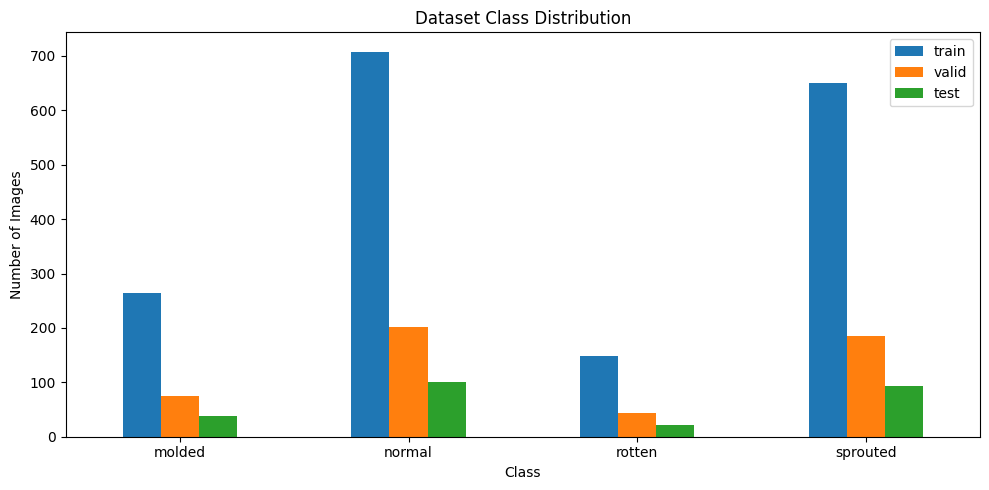

Training imbalance ratio (largest/smallest): 4.75x


In [9]:

# ============================================================
# 4. Inspect class distribution
# ============================================================

IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

def count_images_by_class(folder: Path):
    result = {}
    for class_dir in sorted([p for p in folder.iterdir() if p.is_dir()]):
        count = sum(
            1 for f in class_dir.rglob("*")
            if f.is_file() and f.suffix.lower() in IMAGE_EXTS
        )
        result[class_dir.name] = count
    return result

train_counts = count_images_by_class(TRAIN_DIR)
val_counts = count_images_by_class(VAL_DIR)
test_counts = count_images_by_class(TEST_DIR)

dist_df = pd.DataFrame({
    "train": pd.Series(train_counts),
    "valid": pd.Series(val_counts),
    "test": pd.Series(test_counts),
}).fillna(0).astype(int)

display(dist_df)

total_train = dist_df["train"].sum()
dist_df["train_share_%"] = (100 * dist_df["train"] / total_train).round(2)
display(dist_df[["train", "train_share_%"]])

ax = dist_df[["train", "valid", "test"]].plot(kind="bar", figsize=(10, 5))
ax.set_title("Dataset Class Distribution")
ax.set_xlabel("Class")
ax.set_ylabel("Number of Images")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

largest = dist_df["train"].max()
smallest = dist_df["train"].min()
print(f"Training imbalance ratio (largest/smallest): {largest/smallest:.2f}x")


In [10]:

# ============================================================
# 5. Duplicate / split-leakage check
# ============================================================
# Exact duplicate images across train/valid/test can inflate validation/test
# performance. This checks file-content hashes without changing the dataset.

def image_hash(path: Path, chunk_size=1024 * 1024):
    h = hashlib.sha256()
    with open(path, "rb") as f:
        while True:
            chunk = f.read(chunk_size)
            if not chunk:
                break
            h.update(chunk)
    return h.hexdigest()

def collect_hashes(folder: Path):
    hashes = {}
    for p in folder.rglob("*"):
        if p.is_file() and p.suffix.lower() in IMAGE_EXTS:
            try:
                hashes.setdefault(image_hash(p), []).append(str(p))
            except Exception as e:
                print("Hash skipped:", p, e)
    return hashes

train_hashes = collect_hashes(TRAIN_DIR)
val_hashes = collect_hashes(VAL_DIR)
test_hashes = collect_hashes(TEST_DIR)

train_set = set(train_hashes)
val_set = set(val_hashes)
test_set = set(test_hashes)

train_val_overlap = train_set & val_set
train_test_overlap = train_set & test_set
val_test_overlap = val_set & test_set

print("Exact duplicate hashes across splits:")
print(" train <-> valid:", len(train_val_overlap))
print(" train <-> test :", len(train_test_overlap))
print(" valid <-> test :", len(val_test_overlap))

if train_val_overlap or train_test_overlap or val_test_overlap:
    print("\nWARNING: exact duplicates were found across splits.")
    print("For a strict experiment, remove cross-split duplicates before training.")
else:
    print("\nNo exact cross-split duplicates detected.")


Exact duplicate hashes across splits:
 train <-> valid: 0
 train <-> test : 0
 valid <-> test : 0

No exact cross-split duplicates detected.


In [11]:

# ============================================================
# 6. Build TensorFlow datasets
# ============================================================

train_ds = keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    labels="inferred",
    label_mode="categorical",
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED,
)

class_names = train_ds.class_names
NUM_CLASSES = len(class_names)

val_ds = keras.utils.image_dataset_from_directory(
    VAL_DIR,
    labels="inferred",
    label_mode="categorical",
    class_names=class_names,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    shuffle=False,
)

test_ds = keras.utils.image_dataset_from_directory(
    TEST_DIR,
    labels="inferred",
    label_mode="categorical",
    class_names=class_names,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    shuffle=False,
)

print("Class order:", class_names)
print("Number of classes:", NUM_CLASSES)

with open(CLASS_NAMES_PATH, "w") as f:
    json.dump(class_names, f)

train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.cache().prefetch(AUTOTUNE)
test_ds = test_ds.cache().prefetch(AUTOTUNE)


Found 1772 files belonging to 4 classes.


I0000 00:00:1789825413.776066      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1789825413.779533      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Found 506 files belonging to 4 classes.
Found 253 files belonging to 4 classes.
Class order: ['molded', 'normal', 'rotten', 'sprouted']
Number of classes: 4


In [12]:

# ============================================================
# 7. Class weights for imbalanced training
# ============================================================

y_for_weights = []
for idx, class_name in enumerate(class_names):
    y_for_weights.extend([idx] * int(train_counts[class_name]))

classes_array = np.arange(NUM_CLASSES)

weights = compute_class_weight(
    class_weight="balanced",
    classes=classes_array,
    y=np.array(y_for_weights)
)

class_weight = {i: float(w) for i, w in enumerate(weights)}

print("Balanced class weights:")
for i, name in enumerate(class_names):
    print(f"  {i}: {name:10s} -> {class_weight[i]:.4f}")

# Normalized alpha values for optional focal loss.
alpha = np.array([class_weight[i] for i in range(NUM_CLASSES)], dtype=np.float32)
alpha = alpha / alpha.sum()

print("\nFocal-loss alpha:")
for i, name in enumerate(class_names):
    print(f"  {name:10s} -> {alpha[i]:.4f}")


Balanced class weights:
  0: molded     -> 1.6780
  1: normal     -> 0.6257
  2: rotten     -> 2.9732
  3: sprouted   -> 0.6805

Focal-loss alpha:
  molded     -> 0.2817
  normal     -> 0.1050
  rotten     -> 0.4991
  sprouted   -> 0.1142


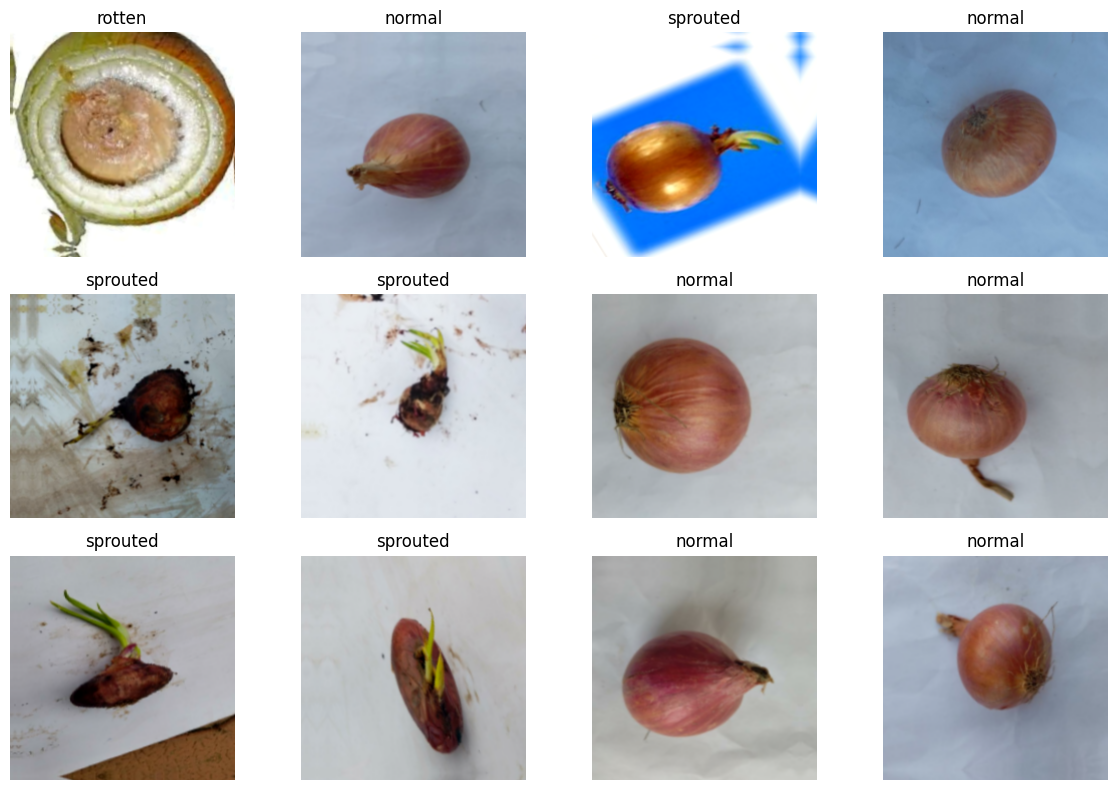

In [13]:

# ============================================================
# 8. Disease-preserving augmentation
# ============================================================
# Avoids aggressive hue/saturation transforms because discoloration can be
# diagnostically relevant for molded/rotten/sprouted onions.

data_augmentation = keras.Sequential(
    [
        layers.RandomFlip("horizontal_and_vertical", seed=SEED),
        layers.RandomRotation(0.08, fill_mode="reflect", seed=SEED),
        layers.RandomZoom(
            height_factor=(-0.12, 0.12),
            width_factor=(-0.12, 0.12),
            fill_mode="reflect",
            seed=SEED,
        ),
        layers.RandomTranslation(
            height_factor=0.08,
            width_factor=0.08,
            fill_mode="reflect",
            seed=SEED,
        ),
        layers.RandomContrast(0.12, seed=SEED),
    ],
    name="augmentation",
)

images, labels = next(iter(train_ds.take(1)))

plt.figure(figsize=(12, 8))
for i in range(min(12, images.shape[0])):
    aug = data_augmentation(images[i:i+1], training=True)[0]
    plt.subplot(3, 4, i + 1)
    plt.imshow(tf.cast(tf.clip_by_value(aug, 0, 255), tf.uint8))
    plt.title(class_names[int(tf.argmax(labels[i]))])
    plt.axis("off")
plt.tight_layout()
plt.show()


In [14]:

# ============================================================
# 9. Optional focal loss
# ============================================================

def categorical_focal_loss(alpha_values, gamma=1.5):
    alpha_tensor = tf.constant(alpha_values, dtype=tf.float32)

    def loss(y_true, y_pred):
        y_pred = tf.clip_by_value(y_pred, keras.backend.epsilon(), 1.0 - keras.backend.epsilon())

        # Label smoothing is applied manually so the same smoothing is used
        # in both focal and ordinary cross-entropy modes.
        if LABEL_SMOOTHING > 0:
            n = tf.cast(tf.shape(y_true)[-1], tf.float32)
            y_true_smoothed = y_true * (1.0 - LABEL_SMOOTHING) + LABEL_SMOOTHING / n
        else:
            y_true_smoothed = y_true

        ce = -y_true_smoothed * tf.math.log(y_pred)
        focal_factor = tf.pow(1.0 - y_pred, gamma)
        alpha_factor = y_true_smoothed * alpha_tensor

        return tf.reduce_sum(alpha_factor * focal_factor * ce, axis=-1)

    return loss

if USE_FOCAL_LOSS:
    loss_fn = categorical_focal_loss(alpha, gamma=FOCAL_GAMMA)
    fit_class_weight = None  # alpha already handles imbalance
    print("Using categorical focal loss.")
else:
    loss_fn = keras.losses.CategoricalCrossentropy(
        label_smoothing=LABEL_SMOOTHING
    )
    fit_class_weight = class_weight if USE_CLASS_WEIGHTS else None
    print("Using categorical cross-entropy.")
    print("Class weights enabled:", USE_CLASS_WEIGHTS)


Using categorical cross-entropy.
Class weights enabled: True


In [15]:

# ============================================================
# 10. Build EfficientNetV2B0 transfer-learning model
# ============================================================

keras.backend.clear_session()

base_model = keras.applications.EfficientNetV2B0(
    include_top=False,
    weights="imagenet",
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    pooling="avg",
    include_preprocessing=True,
)

base_model.trainable = False

inputs = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3), name="image")
x = data_augmentation(inputs)
x = base_model(x, training=False)
x = layers.BatchNormalization(name="head_bn")(x)
x = layers.Dropout(0.35, name="head_dropout_1")(x)
x = layers.Dense(
    256,
    activation="swish",
    kernel_regularizer=regularizers.l2(1e-4),
    name="head_dense",
)(x)
x = layers.Dropout(0.25, name="head_dropout_2")(x)
outputs = layers.Dense(NUM_CLASSES, activation="softmax", name="predictions")(x)

model = keras.Model(inputs, outputs, name="onion_effnetv2b0")
model.summary()


24274472/24274472 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "onion_effnetv2b0"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ image (InputLayer)              │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augmentation (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetv2-b0 (Functional)  │ (None, 1280)           │     5,919,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ head_bn (BatchNormalization)    │ (None, 1280)           │         5,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ head_dropout_1 (Dropout)        │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ head_dense (Dense)              │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ head_dropout_2 (Dropout)        │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,253,396 (23.85 MB)

 Trainable params: 331,524 (1.26 MB)

 Non-trainable params: 5,921,872 (22.59 MB)

In [16]:

# ============================================================
# 11. Imbalance-aware validation callback
# ============================================================
# Computes validation Macro-F1, balanced accuracy, and every class recall at
# the end of each epoch. These metrics are more informative than accuracy
# alone on an imbalanced dataset.

class ImbalanceMetricsCallback(keras.callbacks.Callback):
    def __init__(self, dataset, class_names, prefix="val"):
        super().__init__()
        self.dataset = dataset
        self.class_names = class_names
        self.prefix = prefix

    def on_epoch_end(self, epoch, logs=None):
        logs = logs if logs is not None else {}

        y_true = []
        y_prob = []

        for batch_images, batch_labels in self.dataset:
            probs = self.model.predict(batch_images, verbose=0)
            y_prob.append(probs)
            y_true.append(np.argmax(batch_labels.numpy(), axis=1))

        y_true = np.concatenate(y_true)
        y_prob = np.concatenate(y_prob)
        y_pred = np.argmax(y_prob, axis=1)

        macro_f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)
        bal_acc = balanced_accuracy_score(y_true, y_pred)

        per_class_precision = precision_score(
            y_true, y_pred, average=None,
            labels=np.arange(len(self.class_names)),
            zero_division=0
        )
        per_class_recall = recall_score(
            y_true, y_pred, average=None,
            labels=np.arange(len(self.class_names)),
            zero_division=0
        )
        per_class_f1 = f1_score(
            y_true, y_pred, average=None,
            labels=np.arange(len(self.class_names)),
            zero_division=0
        )

        logs[f"{self.prefix}_macro_f1"] = macro_f1
        logs[f"{self.prefix}_balanced_accuracy"] = bal_acc

        parts = [
            f"{self.prefix}_macro_f1={macro_f1:.4f}",
            f"{self.prefix}_balanced_acc={bal_acc:.4f}"
        ]

        for i, name in enumerate(self.class_names):
            safe = name.lower().replace(" ", "_")
            logs[f"{self.prefix}_{safe}_precision"] = per_class_precision[i]
            logs[f"{self.prefix}_{safe}_recall"] = per_class_recall[i]
            logs[f"{self.prefix}_{safe}_f1"] = per_class_f1[i]
            parts.append(f"{name}_recall={per_class_recall[i]:.3f}")

        print("\n" + " | ".join(parts))


In [17]:

# ============================================================
# 12. Metrics, optimizer, callbacks
# ============================================================

metrics = [
    keras.metrics.CategoricalAccuracy(name="accuracy"),
    keras.metrics.TopKCategoricalAccuracy(k=2, name="top2_accuracy"),
]

def make_callbacks(stage_name):
    imbalance_metrics = ImbalanceMetricsCallback(
        val_ds,
        class_names,
        prefix="val"
    )

    callbacks = [
        # Must run BEFORE ModelCheckpoint so val_macro_f1 is available.
        imbalance_metrics,

        keras.callbacks.ModelCheckpoint(
            BEST_MODEL_PATH,
            monitor="val_macro_f1",
            mode="max",
            save_best_only=True,
            verbose=1,
        ),

        keras.callbacks.ReduceLROnPlateau(
            monitor="val_macro_f1",
            mode="max",
            factor=0.25,
            patience=8,
            min_lr=1e-7,
            verbose=1,
        ),

        keras.callbacks.CSVLogger(
            f"/kaggle/working/{stage_name}_training_log.csv",
            append=False,
        ),

        keras.callbacks.TerminateOnNaN(),
    ]

    if USE_EARLY_STOPPING:
        callbacks.append(
            keras.callbacks.EarlyStopping(
                monitor="val_macro_f1",
                mode="max",
                patience=EARLY_STOP_PATIENCE,
                restore_best_weights=True,
                verbose=1,
            )
        )

    return callbacks


In [18]:

# ============================================================
# 13. Phase 1 — frozen-backbone warm-up
# ============================================================

model.compile(
    optimizer=keras.optimizers.AdamW(
        learning_rate=INITIAL_LR,
        weight_decay=WEIGHT_DECAY,
        clipnorm=1.0,
    ),
    loss=loss_fn,
    metrics=metrics,
)

history_warmup = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=WARMUP_EPOCHS,
    class_weight=fit_class_weight,
    callbacks=make_callbacks("phase1"),
    verbose=1,
)


Epoch 1/30


E0000 00:00:1789825435.935755      58 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/onion_effnetv2b0_1/efficientnetv2-b0_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


55/56 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - accuracy: 0.7678 - loss: 1.0133 - top2_accuracy: 0.8972

2026-09-19 13:44:11.859502: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}



val_macro_f1=0.8939 | val_balanced_acc=0.8952 | molded_recall=1.000 | normal_recall=0.965 | rotten_recall=0.674 | sprouted_recall=0.941

Epoch 1: val_macro_f1 improved from None to 0.89394, saving model to /kaggle/working/onion_effnetv2b0_best_macro_f1.keras

Epoch 1: finished saving model to /kaggle/working/onion_effnetv2b0_best_macro_f1.keras
56/56 ━━━━━━━━━━━━━━━━━━━━ 32s 308ms/step - accuracy: 0.8584 - loss: 0.8065 - top2_accuracy: 0.9509 - val_accuracy: 0.9368 - val_loss: 0.4938 - val_top2_accuracy: 0.9822 - val_macro_f1: 0.8939 - val_balanced_accuracy: 0.8952 - val_molded_precision: 0.7353 - val_molded_recall: 1.0000 - val_molded_f1: 0.8475 - val_normal_precision: 0.9848 - val_normal_recall: 0.9653 - val_normal_f1: 0.9750 - val_rotten_precision: 0.9355 - val_rotten_recall: 0.6744 - val_rotten_f1: 0.7838 - val_sprouted_precision: 1.0000 - val_sprouted_recall: 0.9409 - val_sprouted_f1: 0.9695 - learning_rate: 0.0010
Epoch 2/30
55/56 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.

...

2026-09-19 13:47:30.099072: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


55/56 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 0.9976 - loss: 0.2882 - top2_accuracy: 1.0000
val_macro_f1=0.9314 | val_balanced_acc=0.9319 | molded_recall=0.973 | normal_recall=0.985 | rotten_recall=0.791 | sprouted_recall=0.978

Epoch 29: val_macro_f1 did not improve from 0.94443
56/56 ━━━━━━━━━━━━━━━━━━━━ 7s 126ms/step - accuracy: 0.9949 - loss: 0.2970 - top2_accuracy: 1.0000 - val_accuracy: 0.9644 - val_loss: 0.3395 - val_top2_accuracy: 0.9921 - val_macro_f1: 0.9314 - val_balanced_accuracy: 0.9319 - val_molded_precision: 0.8488 - val_molded_recall: 0.9733 - val_molded_f1: 0.9068 - val_normal_precision: 0.9950 - val_normal_recall: 0.9851 - val_normal_f1: 0.9900 - val_rotten_precision: 0.8947 - val_rotten_recall: 0.7907 - val_rotten_f1: 0.8395 - val_sprouted_precision: 1.0000 - val_sprouted_recall: 0.9785 - val_sprouted_f1: 0.9891 - learning_rate: 6.2500e-05
Epoch 30/30


2026-09-19 13:47:37.175005: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


55/56 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 0.9903 - loss: 0.2993 - top2_accuracy: 0.9982
val_macro_f1=0.9225 | val_balanced_acc=0.9203 | molded_recall=0.973 | normal_recall=0.985 | rotten_recall=0.744 | sprouted_recall=0.978

Epoch 30: val_macro_f1 did not improve from 0.94443
56/56 ━━━━━━━━━━━━━━━━━━━━ 7s 126ms/step - accuracy: 0.9921 - loss: 0.3008 - top2_accuracy: 0.9989 - val_accuracy: 0.9605 - val_loss: 0.3416 - val_top2_accuracy: 0.9921 - val_macro_f1: 0.9225 - val_balanced_accuracy: 0.9203 - val_molded_precision: 0.8202 - val_molded_recall: 0.9733 - val_molded_f1: 0.8902 - val_normal_precision: 0.9950 - val_normal_recall: 0.9851 - val_normal_f1: 0.9900 - val_rotten_precision: 0.9143 - val_rotten_recall: 0.7442 - val_rotten_f1: 0.8205 - val_sprouted_precision: 1.0000 - val_sprouted_recall: 0.9785 - val_sprouted_f1: 0.9891 - learning_rate: 6.2500e-05


2026-09-19 13:47:44.241203: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


In [19]:

# ============================================================
# 14. Phase 2 — fine-tune backbone
# ============================================================

base_model.trainable = True

# Freeze BatchNorm layers during fine-tuning for stability on a small dataset.
for layer in base_model.layers:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False

trainable_count = sum(int(layer.trainable) for layer in base_model.layers)
print(f"Trainable backbone layers: {trainable_count}/{len(base_model.layers)}")

model.compile(
    optimizer=keras.optimizers.AdamW(
        learning_rate=FINE_TUNE_LR,
        weight_decay=WEIGHT_DECAY,
        clipnorm=1.0,
    ),
    loss=loss_fn,
    metrics=metrics,
)

history_finetune = model.fit(
    train_ds,
    validation_data=val_ds,
    initial_epoch=WARMUP_EPOCHS,
    epochs=TOTAL_EPOCHS,
    class_weight=fit_class_weight,
    callbacks=make_callbacks("phase2"),
    verbose=1,
)


Trainable backbone layers: 212/271
Epoch 31/300


E0000 00:00:1789825691.514513      58 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/onion_effnetv2b0_1/efficientnetv2-b0_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 200ms/step - accuracy: 0.9778 - loss: 0.3020 - top2_accuracy: 0.9967

2026-09-19 13:48:34.805772: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}



val_macro_f1=0.9337 | val_balanced_acc=0.9353 | molded_recall=0.987 | normal_recall=0.985 | rotten_recall=0.791 | sprouted_recall=0.978

Epoch 31: val_macro_f1 improved from None to 0.93368, saving model to /kaggle/working/onion_effnetv2b0_best_macro_f1.keras

Epoch 31: finished saving model to /kaggle/working/onion_effnetv2b0_best_macro_f1.keras
56/56 ━━━━━━━━━━━━━━━━━━━━ 54s 434ms/step - accuracy: 0.9855 - loss: 0.3001 - top2_accuracy: 0.9982 - val_accuracy: 0.9664 - val_loss: 0.3392 - val_top2_accuracy: 0.9941 - val_macro_f1: 0.9337 - val_balanced_accuracy: 0.9353 - val_molded_precision: 0.8506 - val_molded_recall: 0.9867 - val_molded_f1: 0.9136 - val_normal_precision: 1.0000 - val_normal_recall: 0.9851 - val_normal_f1: 0.9925 - val_rotten_precision: 0.8947 - val_rotten_recall: 0.7907 - val_rotten_f1: 0.8395 - val_sprouted_precision: 1.0000 - val_sprouted_recall: 0.9785 - val_sprouted_f1: 0.9891 - learning_rate: 3.0000e-05
Epoch 32/300
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 202ms/step - acc

...

2026-09-19 14:52:42.105553: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 196ms/step - accuracy: 0.9980 - loss: 0.2623 - top2_accuracy: 1.0000
val_macro_f1=0.9338 | val_balanced_acc=0.9365 | molded_recall=0.973 | normal_recall=0.980 | rotten_recall=0.814 | sprouted_recall=0.978

Epoch 299: val_macro_f1 did not improve from 0.95773
56/56 ━━━━━━━━━━━━━━━━━━━━ 14s 253ms/step - accuracy: 0.9994 - loss: 0.2651 - top2_accuracy: 1.0000 - val_accuracy: 0.9644 - val_loss: 0.3095 - val_top2_accuracy: 0.9921 - val_macro_f1: 0.9338 - val_balanced_accuracy: 0.9365 - val_molded_precision: 0.8690 - val_molded_recall: 0.9733 - val_molded_f1: 0.9182 - val_normal_precision: 1.0000 - val_normal_recall: 0.9802 - val_normal_f1: 0.9900 - val_rotten_precision: 0.8750 - val_rotten_recall: 0.8140 - val_rotten_f1: 0.8434 - val_sprouted_precision: 0.9891 - val_sprouted_recall: 0.9785 - val_sprouted_f1: 0.9838 - learning_rate: 1.0000e-07
Epoch 300/300


2026-09-19 14:52:56.258198: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 197ms/step - accuracy: 0.9982 - loss: 0.2623 - top2_accuracy: 1.0000
val_macro_f1=0.9338 | val_balanced_acc=0.9365 | molded_recall=0.973 | normal_recall=0.980 | rotten_recall=0.814 | sprouted_recall=0.978

Epoch 300: val_macro_f1 did not improve from 0.95773
56/56 ━━━━━━━━━━━━━━━━━━━━ 14s 254ms/step - accuracy: 0.9989 - loss: 0.2653 - top2_accuracy: 1.0000 - val_accuracy: 0.9644 - val_loss: 0.3093 - val_top2_accuracy: 0.9921 - val_macro_f1: 0.9338 - val_balanced_accuracy: 0.9365 - val_molded_precision: 0.8690 - val_molded_recall: 0.9733 - val_molded_f1: 0.9182 - val_normal_precision: 1.0000 - val_normal_recall: 0.9802 - val_normal_f1: 0.9900 - val_rotten_precision: 0.8750 - val_rotten_recall: 0.8140 - val_rotten_f1: 0.8434 - val_sprouted_precision: 0.9891 - val_sprouted_recall: 0.9785 - val_sprouted_f1: 0.9838 - learning_rate: 1.0000e-07


2026-09-19 14:53:10.473727: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


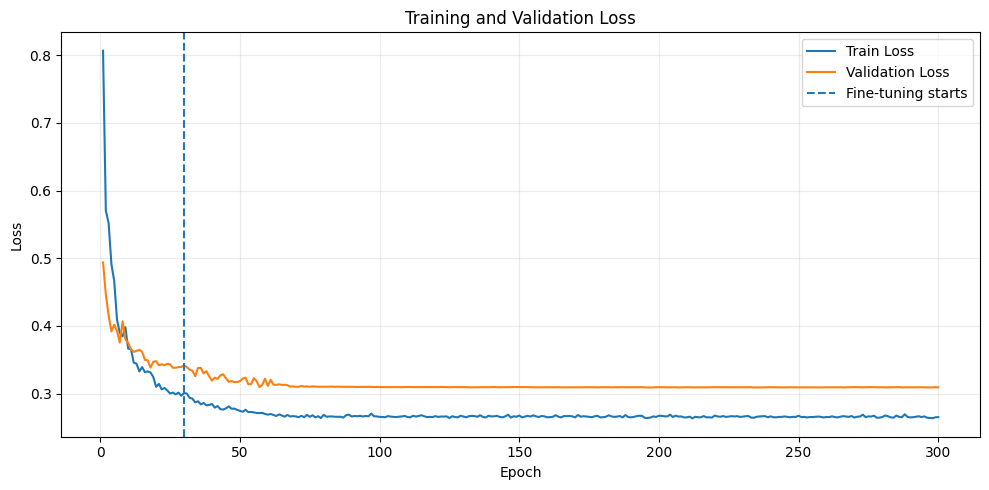

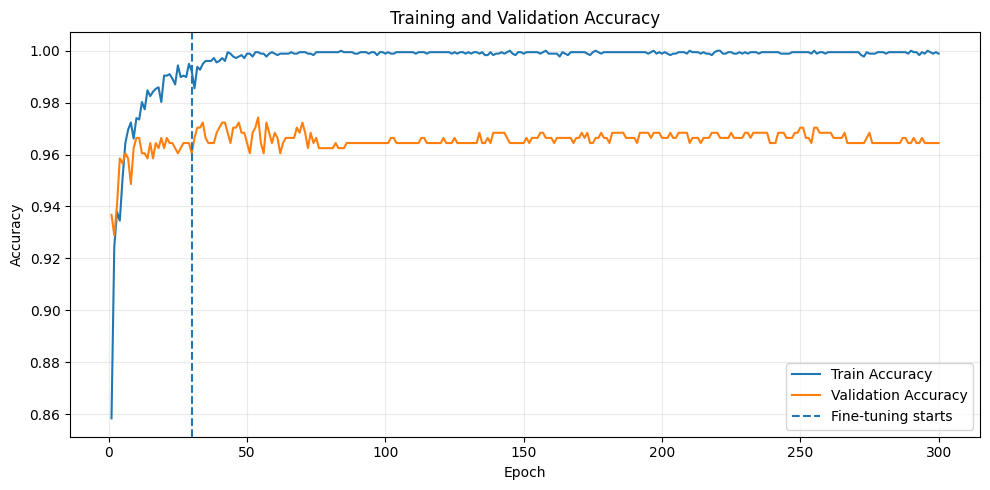

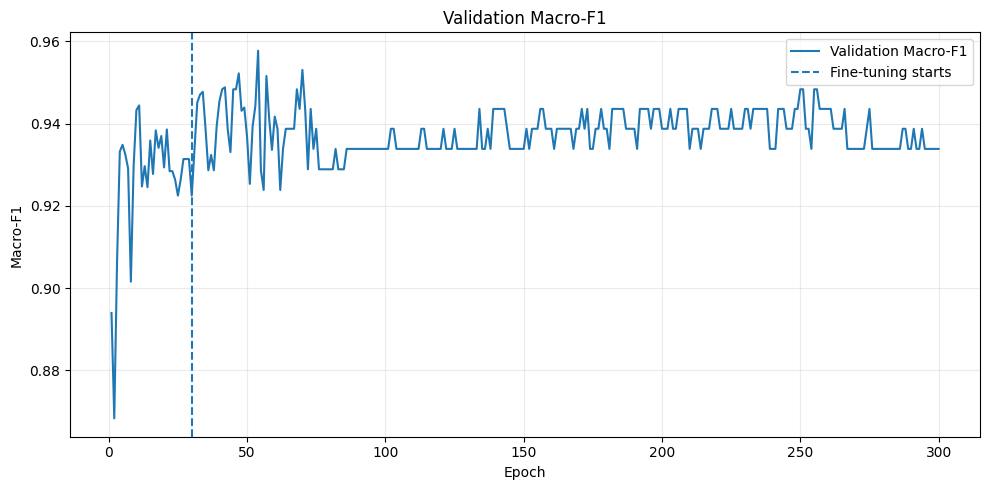

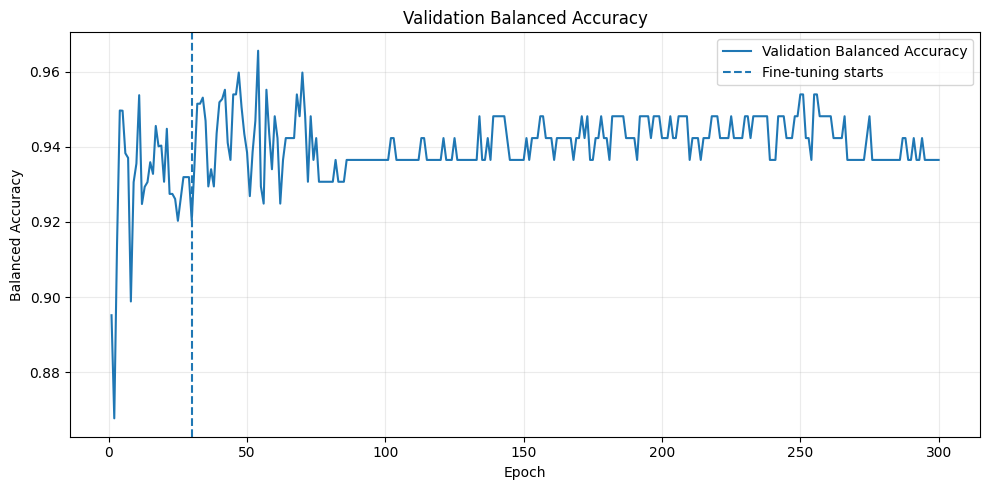

In [20]:

# ============================================================
# 15. Plot training history
# ============================================================

def merge_histories(h1, h2):
    merged = {}
    keys = set(h1.history.keys()) | set(h2.history.keys())
    for key in keys:
        merged[key] = h1.history.get(key, []) + h2.history.get(key, [])
    return merged

history = merge_histories(history_warmup, history_finetune)
epochs_ran = range(1, len(history["loss"]) + 1)

plt.figure(figsize=(10, 5))
plt.plot(epochs_ran, history["loss"], label="Train Loss")
plt.plot(epochs_ran, history["val_loss"], label="Validation Loss")
plt.axvline(WARMUP_EPOCHS, linestyle="--", label="Fine-tuning starts")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(epochs_ran, history["accuracy"], label="Train Accuracy")
plt.plot(epochs_ran, history["val_accuracy"], label="Validation Accuracy")
plt.axvline(WARMUP_EPOCHS, linestyle="--", label="Fine-tuning starts")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

if "val_macro_f1" in history:
    plt.figure(figsize=(10, 5))
    plt.plot(epochs_ran, history["val_macro_f1"], label="Validation Macro-F1")
    plt.axvline(WARMUP_EPOCHS, linestyle="--", label="Fine-tuning starts")
    plt.xlabel("Epoch")
    plt.ylabel("Macro-F1")
    plt.title("Validation Macro-F1")
    plt.legend()
    plt.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()

if "val_balanced_accuracy" in history:
    plt.figure(figsize=(10, 5))
    plt.plot(
        epochs_ran,
        history["val_balanced_accuracy"],
        label="Validation Balanced Accuracy"
    )
    plt.axvline(WARMUP_EPOCHS, linestyle="--", label="Fine-tuning starts")
    plt.xlabel("Epoch")
    plt.ylabel("Balanced Accuracy")
    plt.title("Validation Balanced Accuracy")
    plt.legend()
    plt.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()


8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 69ms/step - accuracy: 0.9802 - loss: 0.2964 - top2_accuracy: 0.9960

Best-checkpoint test metrics:
accuracy: 0.98024
loss: 0.29641
top2_accuracy: 0.99605


2026-09-19 14:53:21.131408: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}



Test Macro-F1:          0.9758
Test Weighted-F1:       0.9803
Test Balanced Accuracy: 0.9737

Classification Report:
              precision    recall  f1-score   support

      molded     1.0000    0.9737    0.9867        38
      normal     0.9709    0.9901    0.9804       101
      rotten     0.9524    0.9524    0.9524        21
    sprouted     0.9891    0.9785    0.9838        93

    accuracy                         0.9802       253
   macro avg     0.9781    0.9737    0.9758       253
weighted avg     0.9804    0.9802    0.9803       253



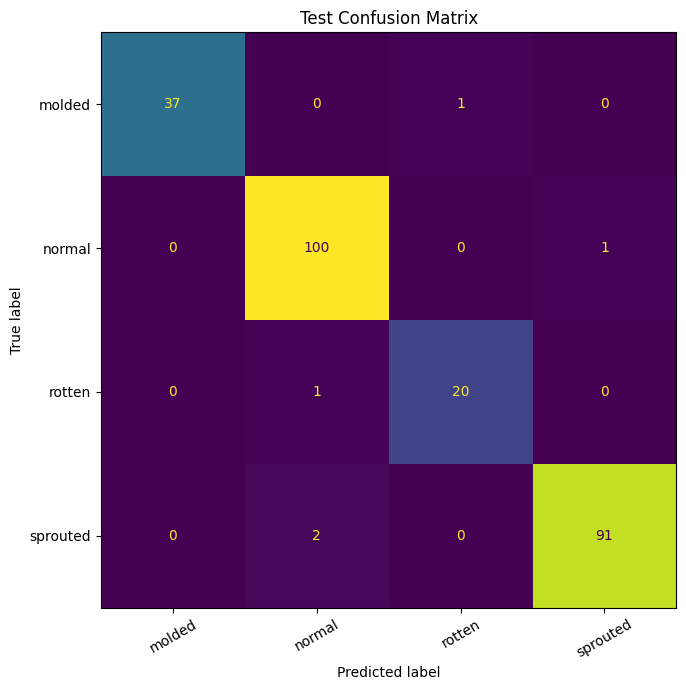

In [21]:

# ============================================================
# 16. Test-set evaluation using BEST Macro-F1 checkpoint
# ============================================================

best_model = keras.models.load_model(
    BEST_MODEL_PATH,
    custom_objects={"loss": loss_fn} if USE_FOCAL_LOSS else None
)

test_results = best_model.evaluate(test_ds, verbose=1, return_dict=True)

print("\nBest-checkpoint test metrics:")
for k, v in test_results.items():
    print(f"{k}: {v:.5f}")

y_true = []
y_prob = []

for batch_images, batch_labels in test_ds:
    probs = best_model.predict(batch_images, verbose=0)
    y_prob.append(probs)
    y_true.append(np.argmax(batch_labels.numpy(), axis=1))

y_true = np.concatenate(y_true)
y_prob = np.concatenate(y_prob)
y_pred = np.argmax(y_prob, axis=1)

macro_f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)
weighted_f1 = f1_score(y_true, y_pred, average="weighted", zero_division=0)
bal_acc = balanced_accuracy_score(y_true, y_pred)

print(f"\nTest Macro-F1:          {macro_f1:.4f}")
print(f"Test Weighted-F1:       {weighted_f1:.4f}")
print(f"Test Balanced Accuracy: {bal_acc:.4f}")

print("\nClassification Report:")
print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names,
        digits=4,
        zero_division=0,
    )
)

cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(7, 7))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)
disp.plot(ax=ax, values_format="d", colorbar=False)
plt.title("Test Confusion Matrix")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


In [22]:

# ============================================================
# 17. Per-class precision / recall / F1 table
# ============================================================

report_dict = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    digits=4,
    zero_division=0,
    output_dict=True,
)

report_df = pd.DataFrame(report_dict).T
display(report_df)

per_class_df = report_df.loc[class_names, ["precision", "recall", "f1-score", "support"]].copy()
per_class_df["support"] = per_class_df["support"].astype(int)

print("\nPer-class test performance:")
display(per_class_df)

# Minority-class warning
train_series = pd.Series(train_counts).reindex(class_names)
minority_classes = train_series.sort_values().index[:2].tolist()

print("Minority classes by training count:", minority_classes)
for c in minority_classes:
    rec = float(per_class_df.loc[c, "recall"])
    if rec < 0.75:
        print(
            f"WARNING: {c} recall is {rec:.3f}. "
            "Consider enabling USE_FOCAL_LOSS=True and retraining."
        )

report_df.to_csv("/kaggle/working/test_classification_report.csv")
per_class_df.to_csv("/kaggle/working/test_per_class_metrics.csv")


,precision,recall,f1-score,support
molded,1.000000,0.973684,0.986667,38.000000
normal,0.970874,0.990099,0.980392,101.000000
rotten,0.952381,0.952381,0.952381,21.000000
sprouted,0.989130,0.978495,0.983784,93.000000
accuracy,0.980237,0.980237,0.980237,0.980237
macro avg,0.978096,0.973665,0.975806,253.000000
weighted avg,0.980424,0.980237,0.980256,253.000000



Per-class test performance:


,precision,recall,f1-score,support
molded,1.000000,0.973684,0.986667,38
normal,0.970874,0.990099,0.980392,101
rotten,0.952381,0.952381,0.952381,21
sprouted,0.989130,0.978495,0.983784,93


Minority classes by training count: ['rotten', 'molded']


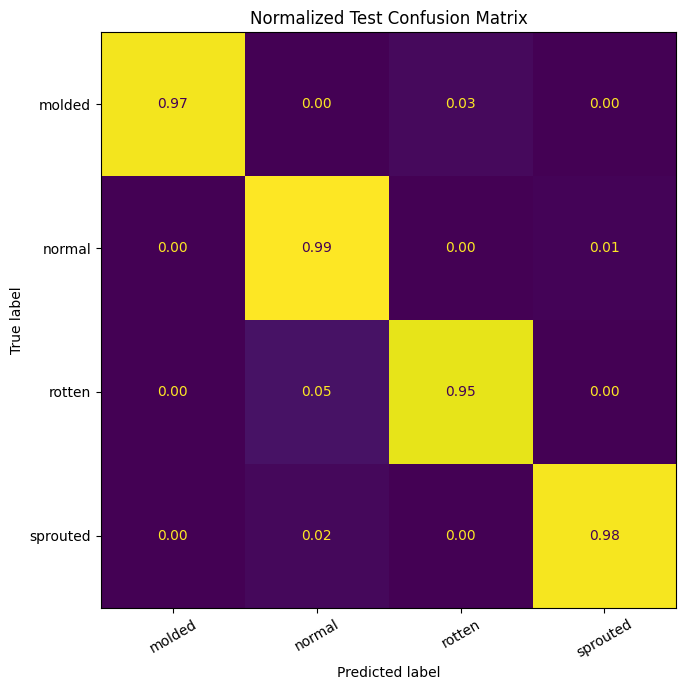

In [23]:

# ============================================================
# 18. Normalized confusion matrix
# ============================================================

cm_norm = confusion_matrix(
    y_true,
    y_pred,
    normalize="true"
)

fig, ax = plt.subplots(figsize=(7, 7))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_norm,
    display_labels=class_names
)
disp.plot(ax=ax, values_format=".2f", colorbar=False)
plt.title("Normalized Test Confusion Matrix")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


Misclassified test images: 5


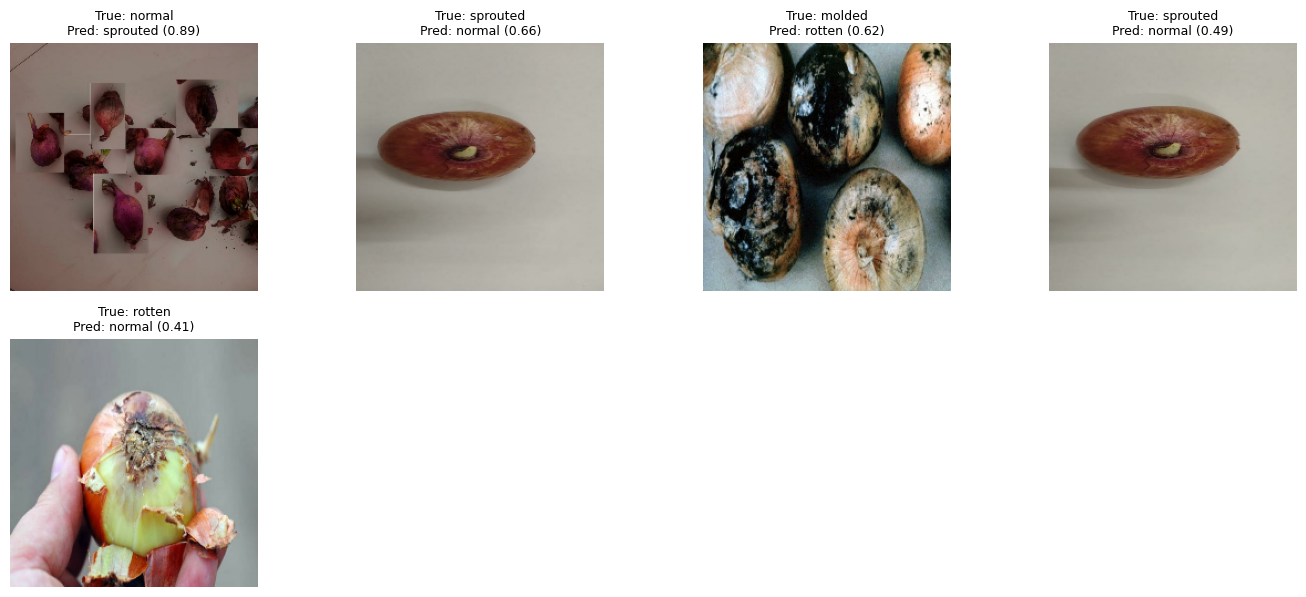

In [24]:

# ============================================================
# 19. Inspect misclassified test images
# ============================================================

misclassified = np.where(y_true != y_pred)[0]
print("Misclassified test images:", len(misclassified))

if len(misclassified) > 0:
    test_images_np = np.concatenate(
        [x.numpy().astype(np.uint8) for x, _ in test_ds],
        axis=0
    )

    # Show highest-confidence mistakes first.
    wrong_conf = np.max(y_prob[misclassified], axis=1)
    order = np.argsort(-wrong_conf)
    selected = misclassified[order[: min(16, len(misclassified))]]

    plt.figure(figsize=(14, 12))
    for plot_idx, data_idx in enumerate(selected):
        plt.subplot(4, 4, plot_idx + 1)
        plt.imshow(test_images_np[data_idx])
        confidence = float(np.max(y_prob[data_idx]))
        plt.title(
            f"True: {class_names[y_true[data_idx]]}\n"
            f"Pred: {class_names[y_pred[data_idx]]} ({confidence:.2f})",
            fontsize=9,
        )
        plt.axis("off")
    plt.tight_layout()
    plt.show()
else:
    print("No misclassifications found.")


In [25]:

# ============================================================
# 20. Save final model and metadata
# ============================================================

# Save final epoch model separately from best validation Macro-F1 model.
model.save(FINAL_MODEL_PATH)

metadata = {
    "model": "EfficientNetV2B0",
    "image_size": IMG_SIZE,
    "classes": class_names,
    "train_counts": train_counts,
    "valid_counts": val_counts,
    "test_counts": test_counts,
    "class_weight": class_weight,
    "use_class_weights": USE_CLASS_WEIGHTS,
    "use_focal_loss": USE_FOCAL_LOSS,
    "focal_gamma": FOCAL_GAMMA,
    "total_epochs_configured": TOTAL_EPOCHS,
    "warmup_epochs": WARMUP_EPOCHS,
    "fine_tune_epochs": FINE_TUNE_EPOCHS,
    "label_smoothing": LABEL_SMOOTHING,
    "weight_decay": WEIGHT_DECAY,
    "checkpoint_monitor": "val_macro_f1",
    "test_macro_f1": float(macro_f1),
    "test_weighted_f1": float(weighted_f1),
    "test_balanced_accuracy": float(bal_acc),
    "best_model_path": BEST_MODEL_PATH,
    "final_model_path": FINAL_MODEL_PATH,
}

with open("/kaggle/working/onion_model_metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)

print("Saved:")
print(" ", BEST_MODEL_PATH)
print(" ", FINAL_MODEL_PATH)
print(" ", CLASS_NAMES_PATH)
print(" ", "/kaggle/working/onion_model_metadata.json")
print(" ", "/kaggle/working/test_classification_report.csv")
print(" ", "/kaggle/working/test_per_class_metrics.csv")


Saved:
  /kaggle/working/onion_effnetv2b0_best_macro_f1.keras
  /kaggle/working/onion_effnetv2b0_final.keras
  /kaggle/working/onion_class_names.json
  /kaggle/working/onion_model_metadata.json
  /kaggle/working/test_classification_report.csv
  /kaggle/working/test_per_class_metrics.csv


In [26]:

# ============================================================
# 21. Single-image inference helper
# ============================================================

def predict_onion_image(image_path, trained_model=best_model):
    img = keras.utils.load_img(
        image_path,
        target_size=(IMG_SIZE, IMG_SIZE),
    )
    arr = keras.utils.img_to_array(img)
    arr = tf.expand_dims(arr, axis=0)

    probs = trained_model.predict(arr, verbose=0)[0]
    pred_idx = int(np.argmax(probs))

    return {
        "predicted_class": class_names[pred_idx],
        "confidence": float(probs[pred_idx]),
        "probabilities": {
            class_names[i]: float(probs[i])
            for i in range(NUM_CLASSES)
        },
    }

# Example:
# print(predict_onion_image("/kaggle/input/your-image-folder/example.jpg"))



## What was added specifically for the class imbalance

1. **Balanced class weights** so minority-class errors matter more during training.
2. **Macro-F1** as the primary validation checkpoint metric rather than plain accuracy.
3. **Balanced accuracy** monitoring.
4. **Per-class precision, recall, and F1** so `rotten` and `molded` performance cannot be hidden by strong majority-class accuracy.
5. **Normalized confusion matrix** for class-by-class error analysis.
6. **Optional focal loss** for a second training run if minority-class recall remains weak.
7. **Disease-preserving augmentation** that avoids heavy color distortion.
8. **Duplicate/leakage check** across train/valid/test splits.
9. **Highest-confidence misclassification review** to identify labeling or visual ambiguity problems.

### Recommended workflow

Run the notebook first with:

```python
USE_FOCAL_LOSS = False
USE_CLASS_WEIGHTS = True
```

This is the safer baseline.

After training, inspect `rotten` and `molded` recall. If either is still clearly weak, make a second Kaggle run with:

```python
USE_FOCAL_LOSS = True
```

When focal loss is enabled, the notebook automatically disables `class_weight` during `fit()` so the minority classes are not accidentally weighted twice.

### Kaggle settings
- Accelerator: **GPU**
- Run all cells in order
- The best model is selected by **validation Macro-F1**, not the final epoch
- The final model and best model are both saved under `/kaggle/working/`
